<a href="https://colab.research.google.com/github/lakithav/ml-internship-journey/blob/main/Outlier_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
path = "/content/drive/MyDrive/DataSets/insurance.csv"
data = pd.read_csv(path)
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
data.shape

(1338, 7)

Text(0, 0.5, 'Count')

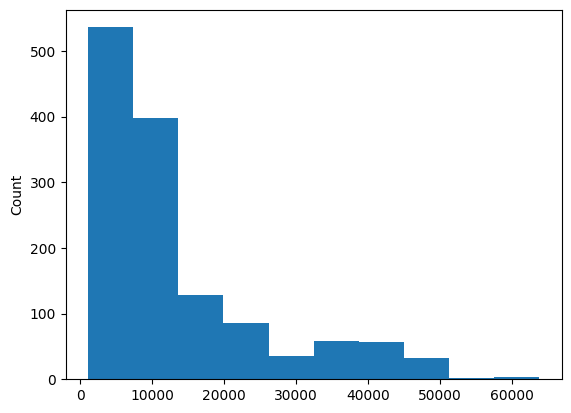

In [9]:
plt.hist(data['charges'])
plt.ylabel('Count')

In [15]:
mean = np.mean(data['charges'])
print(mean)

13270.422265141257


In [13]:
std = np.std(data['charges'])
std

12105.484975561605

In [16]:
(data['charges']-mean)/std

,charges
0,0.298584
1,-0.953689
2,-0.728675
3,0.719843
4,-0.776802
...,...
1333,-0.220551
1334,-0.914002
1335,-0.961596
1336,-0.930362


In [17]:
data['charges_zscore'] = (data['charges']-mean)/std

In [18]:
data.head()

,age,sex,bmi,children,smoker,region,charges,charges_zscore
0,19,female,27.900,0,yes,southwest,16884.92400,0.298584
1,18,male,33.770,1,no,southeast,1725.55230,-0.953689
2,28,male,33.000,3,no,southeast,4449.46200,-0.728675
3,33,male,22.705,0,no,northwest,21984.47061,0.719843
4,32,male,28.880,0,no,northwest,3866.85520,-0.776802


In [21]:
data[data['charges_zscore'] > 3]

,age,sex,bmi,children,smoker,region,charges,charges_zscore
34,28,male,36.400,1,yes,southwest,51194.55914,3.132806
543,54,female,47.410,0,yes,southeast,63770.42801,4.171663
577,31,female,38.095,1,yes,northeast,58571.07448,3.742159
819,33,female,35.530,0,yes,northwest,55135.40209,3.458348
1146,60,male,32.800,0,yes,southwest,52590.82939,3.248148
1230,52,male,34.485,3,yes,northwest,60021.39897,3.861966
1300,45,male,30.360,0,yes,southeast,62592.87309,4.074389


In [22]:
data[data['charges_zscore'] < -3]

,age,sex,bmi,children,smoker,region,charges,charges_zscore


In [23]:
data['charges_zscore'].min()

-1.0035573452584996

In [26]:
data['charges_zscore'].max()

4.1716631631700425

In [27]:
outlier_indexes = []

In [30]:
outlier_indexes.extend(data.index[data['charges_zscore']>3].tolist())

In [31]:
outlier_indexes

[34, 543, 577, 819, 1146, 1230, 1300]

In [32]:
new_data = data.drop(data.index[outlier_indexes])

In [33]:
new_data.shape

(1331, 8)

In [34]:
data.shape[0],new_data.shape[0]

(1338, 1331)

In [38]:
new_data = new_data.drop('charges_zscore',axis=1)

(array([423., 338., 228.,  85.,  66.,  39.,  26.,  53.,  42.,  31.]),
 array([ 1121.8739 ,  5967.45275, 10813.0316 , 15658.61045, 20504.1893 ,
        25349.76815, 30195.347  , 35040.92585, 39886.5047 , 44732.08355,
        49577.6624 ]),
 <BarContainer object of 10 artists>)

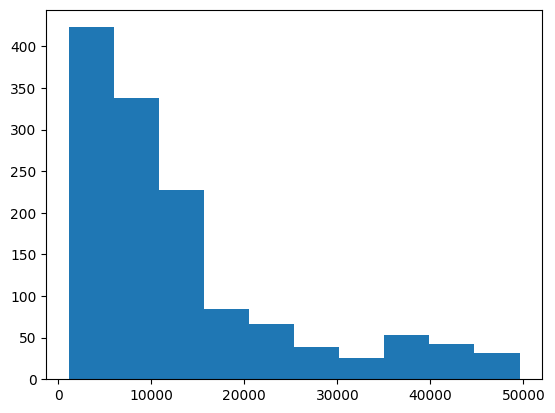

In [39]:
plt.hist(new_data['charges'])
